In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/traffic_dataset_finalized_536k.csv"
df = pd.read_csv(path)


In [3]:
import numpy as np

df["byte_rate"] = df["byte_count"] / df["duration_sec"]

df["packet_rate"] = df["packet_count"] / df["duration_sec"]

df["avg_packet_size"] = df["byte_count"] / df["packet_count"]

df["throughput"] = (df["byte_count"] * 8) / df["duration_sec"]

df["flow_intensity"] = df["packet_count"] / (df["duration_sec"] + 1)

df["burst_ratio"] = df["packet_rate"] / (df["byte_rate"] + 1)

df["log_byte_count"] = np.log1p(df["byte_count"])

df["log_throughput"] = np.log1p(df["throughput"])

df.to_csv("/content/drive/MyDrive/traffic_dataset_features.csv", index=False)

In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/traffic_dataset_features.csv")

# remove redundant column
df = df.drop(columns=["packet_size"])

# save updated dataset
df.to_csv("/content/drive/MyDrive/traffic_dataset_features_final.csv", index=False)

print("Column removed and dataset saved")

Column removed and dataset saved


In [5]:
!pip install lightgbm

In [6]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/traffic_dataset_features_final.csv")

In [7]:
df.head()

,dpid,packet_count,byte_count,duration_sec,label,byte_rate,packet_rate,avg_packet_size,throughput,flow_intensity,burst_ratio,log_byte_count,log_throughput
0,1,17140.0,24578760.0,21.680922,eMBB,1.133658e+06,790.556802,1434.0,9.069268e+06,755.701216,0.000697,17.017393,16.020402
1,1,6385.0,9175245.0,6.050921,eMBB,1.516339e+06,1055.211212,1437.0,1.213071e+07,905.555420,0.000696,16.032020,16.311251
2,1,12140.0,17335920.0,15.852906,eMBB,1.093548e+06,765.790198,1428.0,8.748387e+06,720.350545,0.000700,16.668291,15.984380
3,1,18091.0,25779675.0,16.860257,eMBB,1.529020e+06,1072.996695,1425.0,1.223216e+07,1012.919357,0.000702,17.065097,16.319579
4,1,7602.0,9456888.0,18.343689,eMBB,5.155390e+05,414.420456,1244.0,4.124312e+06,392.996391,0.000804,16.062254,15.232410


In [8]:
X = df.drop(columns=["label"])  # features
y = df["label"]                 # target

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2810
[LightGBM] [Info] Number of data points in the train set: 429408, number of used features: 12
[LightGBM] [Info] Start training from score -0.229230
[LightGBM] [Info] Start training from score -1.634034
[LightGBM] [Info] Start training from score -4.634252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=200)

In [12]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

Precision: 0.9993160455014449
Recall: 0.9993199940383038
F1 Score: 0.9993104607262203
Accuracy: 0.9993199940383038


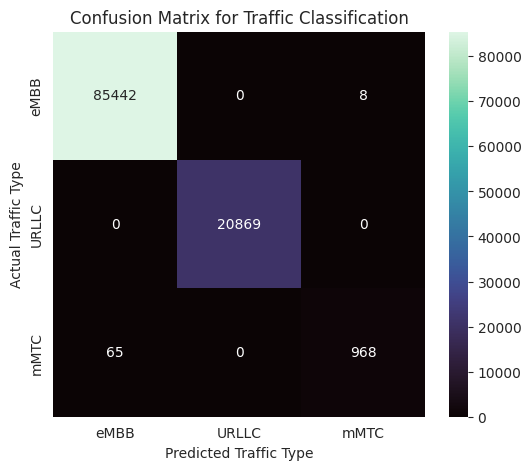

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["eMBB", "URLLC", "mMTC"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="mako",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Traffic Type")
plt.ylabel("Actual Traffic Type")
plt.title("Confusion Matrix for Traffic Classification")
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_512/2434570789.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


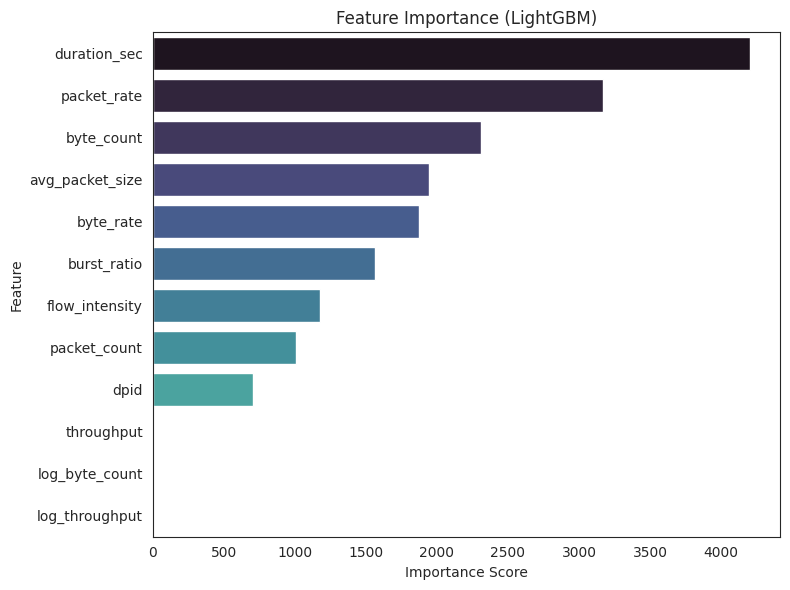

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create importance dataframe
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.set_style("white")

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="mako"
)

plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_512/3248799174.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


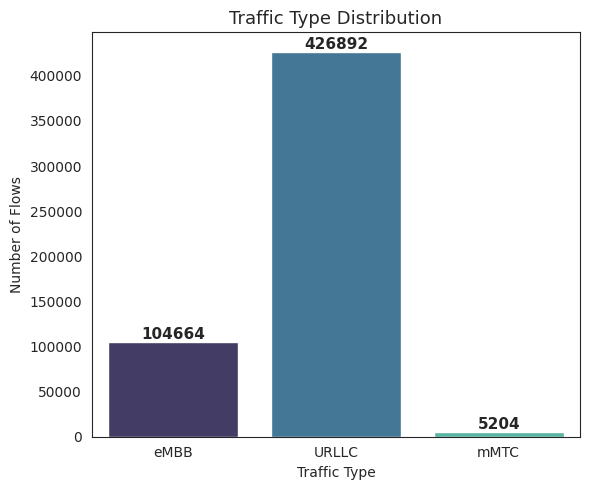

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x=df["label"],
    palette=sns.color_palette("mako", 3)   # mako colors
)

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight="bold"
    )

plt.title("Traffic Type Distribution", fontsize=13)
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/traffic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

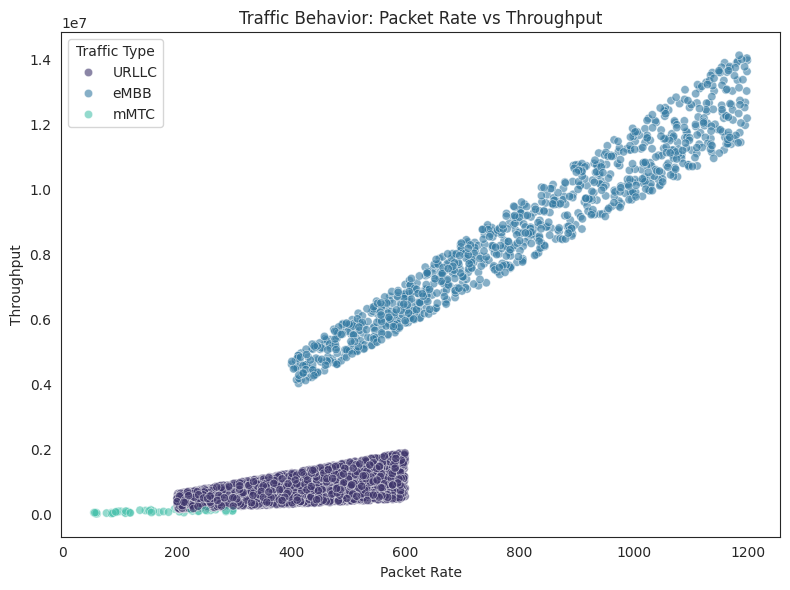

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000),
    x="packet_rate",
    y="throughput",
    hue="label",
    palette=sns.color_palette("mako", 3),   # mako colors
    alpha=0.6
)

plt.title("Traffic Behavior: Packet Rate vs Throughput")
plt.xlabel("Packet Rate")
plt.ylabel("Throughput")
plt.legend(title="Traffic Type")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

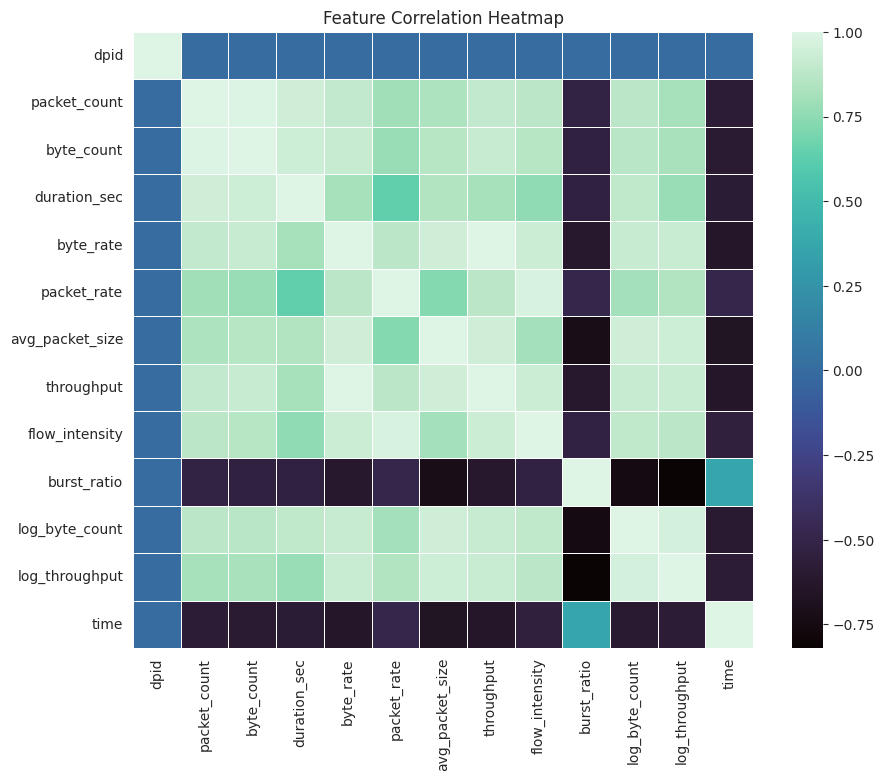

In [40]:
plt.figure(figsize=(10,8))

corr = df.drop(columns=["label"]).corr()

sns.heatmap(
    corr,
    cmap="mako",
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.savefig(
    "/content/drive/MyDrive/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()